In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

IMAGES_DIR = PROJECT_ROOT / 'images'
DATA_DIR = PROJECT_ROOT / 'data'

# Introduction

What is this data set and what are we looking to learn from it. 

### Main question
### Which factors impact list price?

We will investigate things like

smartwatch model 

special editions

premium options such as titanium, ceramic or special bands

case size

aftermarket additions

country of origin

'power seller' vs individual

# Organization of the document

data cleaning and validation

feature extraction

fitting a regression model

## The story

Extract model. 

Plot model vs price, old models expensive.

Many are gold plated.

Even so many old models are so expensive. Limitiations of data.

Extract Hermes and titanium.

Run OLS model. See UK is very cheap.

Investigate UK, are prices there normal? Yes. 

Wrap-up:
Aftermarket gold-plating increases list price a lot. Old models still maintain a constant list price (violin plot). Country of origin affects price too.

Limitations of dataset. List, not sold.

# Importing and cleaning the data

In [2]:
import pandas as pd

In [3]:
path= DATA_DIR/ 'Global_Smartwatch_Marketplace.csv'
df = pd.read_csv(path)

pd.set_option('display.max_colwidth', None)

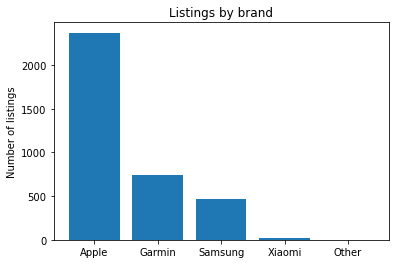

In [4]:
import matplotlib.pyplot as plt

plt.bar(df['brand'].value_counts().index, df['brand'].value_counts())

plt.title('Listings by brand')
plt.ylabel('Number of listings')
plt.Figure(figsize = (16,9), layout='tight')

plt.show()

In [5]:
df.columns

Index(['brand', 'condition', 'Case_Size_mm', 'Country', 'price', 'Seller_ID',
       'Is_Worldwide_Shipping', 'title'],
      dtype='object')

We standardize the text in the columns, their names, remove bundles and non smartwatch listings, and restrict to only Apple branded watches.

In [6]:
from src.cleaning import clean_dataframe


df = clean_dataframe(df)

In [7]:
df.describe()

,case_size,price,worldwide_shipping
count,2017.000000,2333.000000,2333.000000
mean,46.222608,577.412327,0.160737
std,3.102023,152.305166,0.367367
min,38.000000,120.000000,0.000000
25%,44.000000,458.490000,0.000000
50%,46.000000,550.000000,0.000000
75%,49.000000,669.480000,0.000000
max,49.000000,1199.000000,1.000000


# Extracting model from the title column




First, we use regex to extract the model and family from the 'title' column, then we'll plot model and family by number of listings.

In [8]:
from src.feature_engineering import add_model_col, add_family_col
from src.graphics import plot_by

In [9]:
df = add_model_col(df)
df = add_family_col(df)

## Listings by Model and by Family

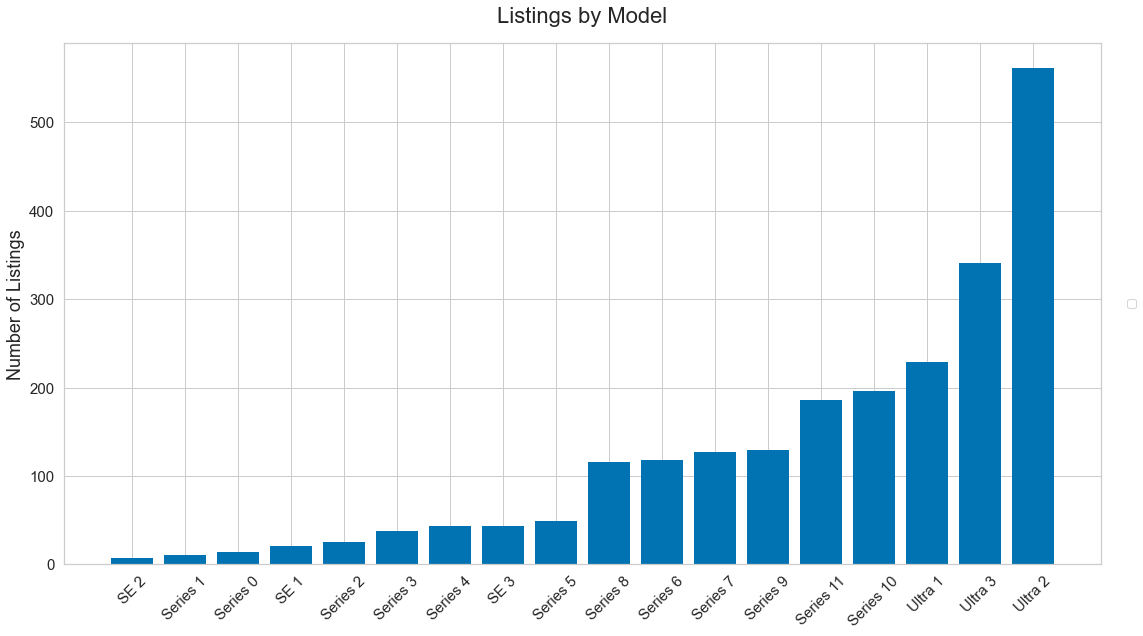

In [10]:
plot_by(
    df,
    by='count',
    ylabel = 'Number of Listings',
    save_path=IMAGES_DIR / 'model_count.png',
    title = 'Listings by Model'
)

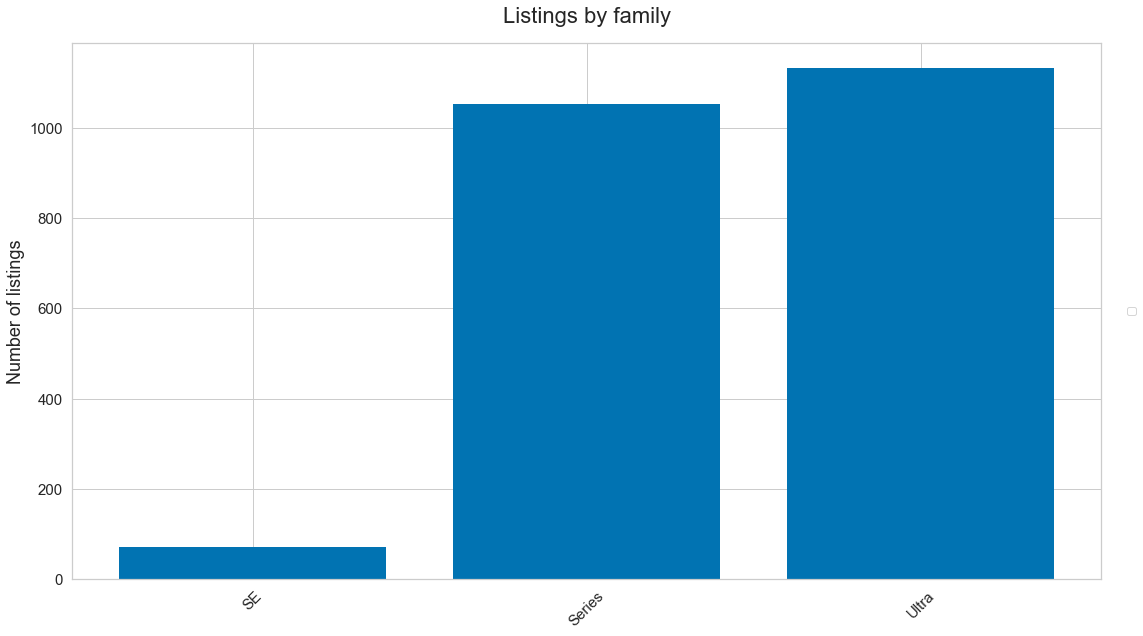

In [11]:
plot_by(
    df,
    column = 'family',
    by='count',
    save_path=IMAGES_DIR / 'family_count.png',
    title = 'Listings by family',
    ylabel = 'Number of listings'
)

### Key insights:

Most listings come from the last three generations of Series and Ultra models: Ultra 1,2,3 and Series 9,10,11. 

Ultra series have the most listings.

SE models have among fewest listings. 

##  Average price by model

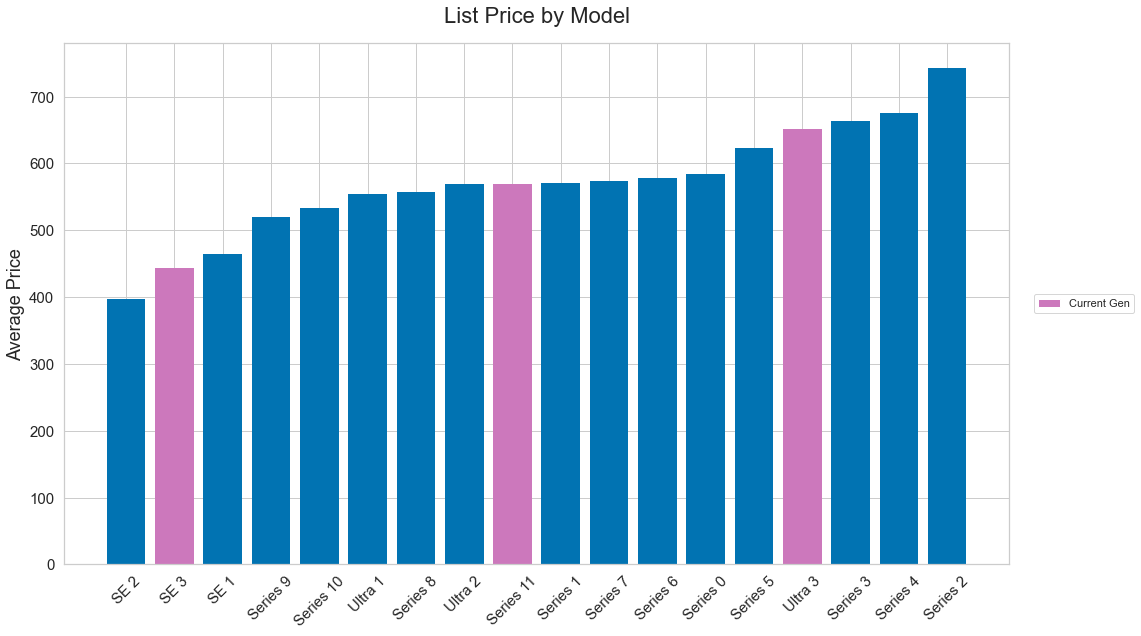

In [12]:
current_gen_models = ['Ultra 3', 'Series 11', 'SE 3']

plot_by(
    df, 
    by='mean', 
    highlight_models = current_gen_models, 
    highlight_labels = ['Current Gen'],
    save_path=IMAGES_DIR / 'price_by_model_all.png', 
    title = 'List Price by Model', 
    ylabel = 'Average Price'
)

We would expect that the two newest models, ultra 3 and series 11 would sell for the most. Why then are series 2, 4, and 3 - outdated models - are selling for more on average than the newest Ultra 3?

Looking through the series 2 data, we notice a lot of them are aftermarket 24k gold-plated.
Let's extract these features, along with a few other luxury markers.

## Extract aftermarket gold plating as feature

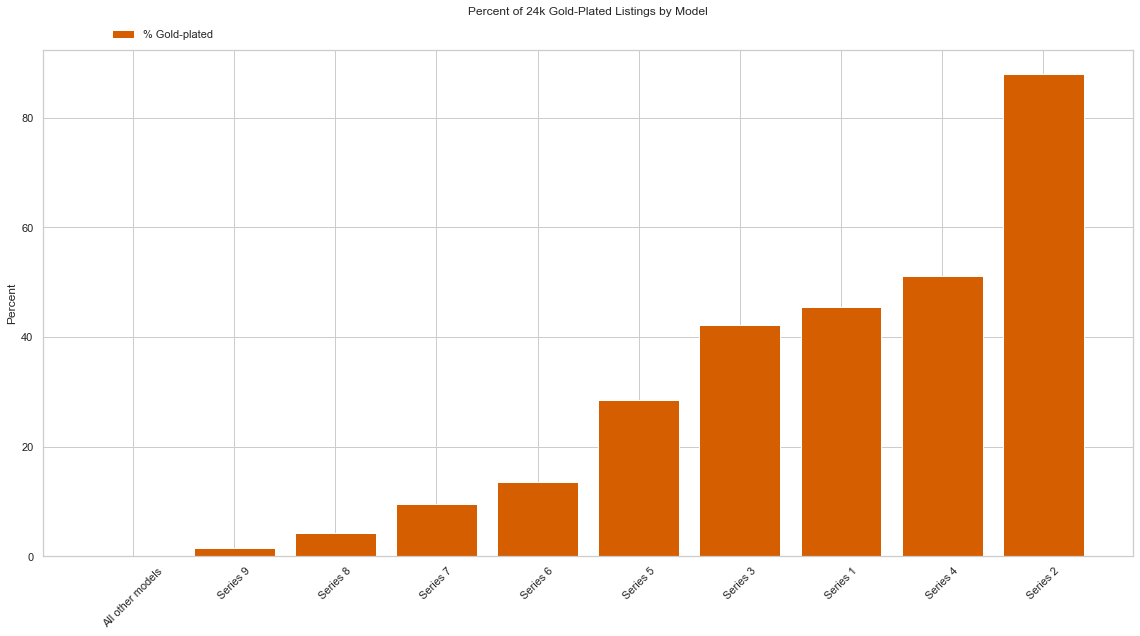

In [13]:
from src.feature_engineering import add_premium_cols
df = add_premium_cols(df)

from src.graphics import plot_gold_percentage
plot_gold_percentage(df, model_list = (df['model'].dropna()).unique(), save_path=IMAGES_DIR / 'gold_plated.png')

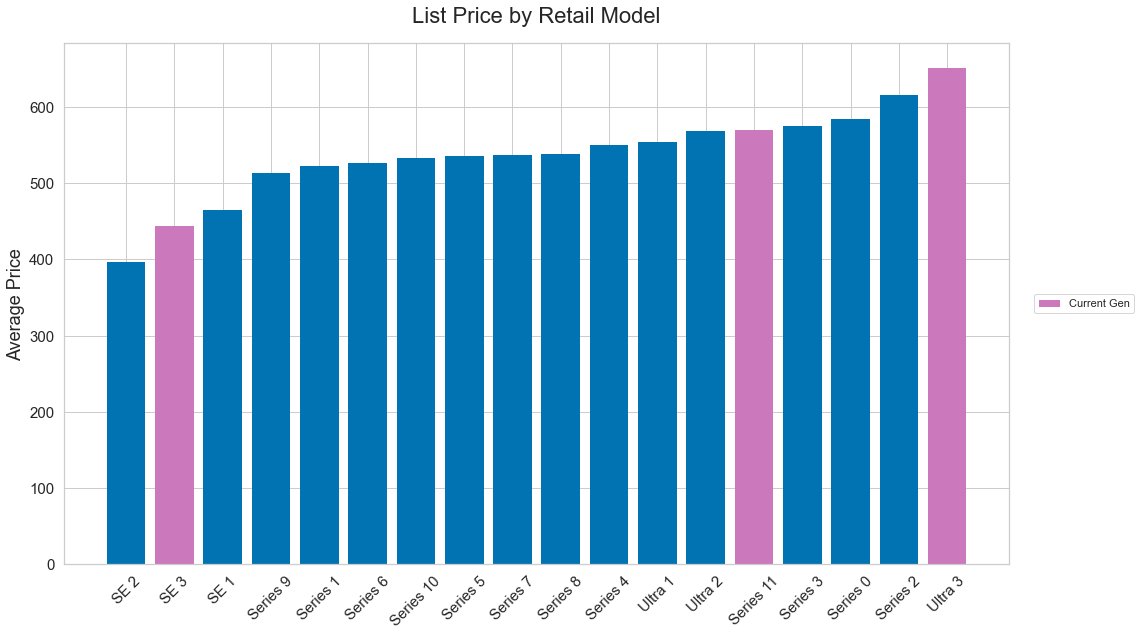

In [14]:
retail_models = df[df['gold']==0]

plot_by(retail_models,
        by='mean',
        title = 'List Price by Retail Model',
        save_path=IMAGES_DIR / 'price_by_model_retail.png',
        highlight_models = current_gen_models,
        highlight_labels = ['Current gen'],
        ylabel = 'Average Price'
       )



This says in particular that around 90% of all series 2 models are acually aftermarked 24k gold-plated.

Notice also that this affects none of the current-gen models.


### How much more do gold plated models sell for?

In [15]:
from src.other import calculate_price_increase

In [16]:
gold_dollar, gold_percent = calculate_price_increase(df, 'gold')
hermes_dollar, hermes_percent = calculate_price_increase(df, 'hermes')


print(f'Gold-plated models sell for ${gold_dollar}, or {gold_percent} percent more.')
print(f'Hermes models sell for ${hermes_dollar}, or {hermes_percent} percent more.')

Gold-plated models sell for $292, or 54.3 percent more.
Hermes models sell for $122, or 23.1 percent more.


We filter by 'retail models', i.e. models which are not gold-plated to account for this aftermarket difference.

In [17]:
retail_models = (df[df['gold']==0])

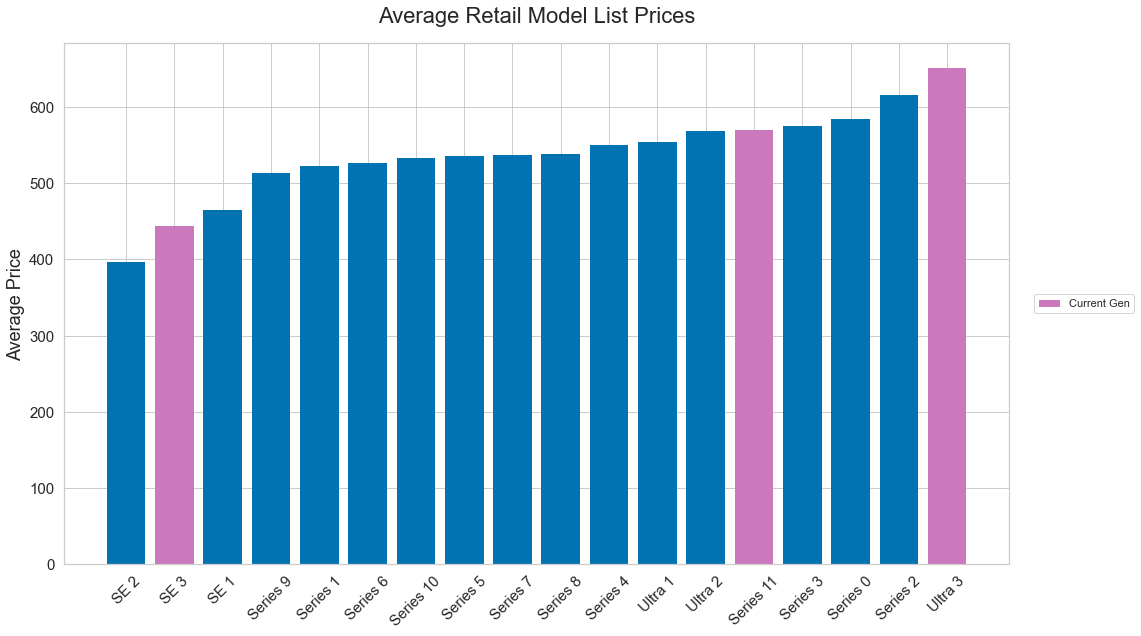

In [18]:
plot_by(retail_models,
        by='mean',
        title = 'Average Retail Model List Prices',
        save_path=IMAGES_DIR / 'standard_models.png',
        highlight_models = current_gen_models,
        highlight_labels = ['Current gen'],
        ylabel = 'Average Price'
       )



### Key insight:

The latest Ultra 3 is now priced highest, so gold-plating accounts for some of the price, but not all.

### New Observation:

Standard Series models are all priced in the 500-600 dollar range, regardless of model.

#### Sanity check
However, we need to keep in mind that the spread of listings is heavily left-skewed. We'll look at a weighted average of price now, adding more weight to models with a greater number of listings. Including gold-plated aftermarket models.

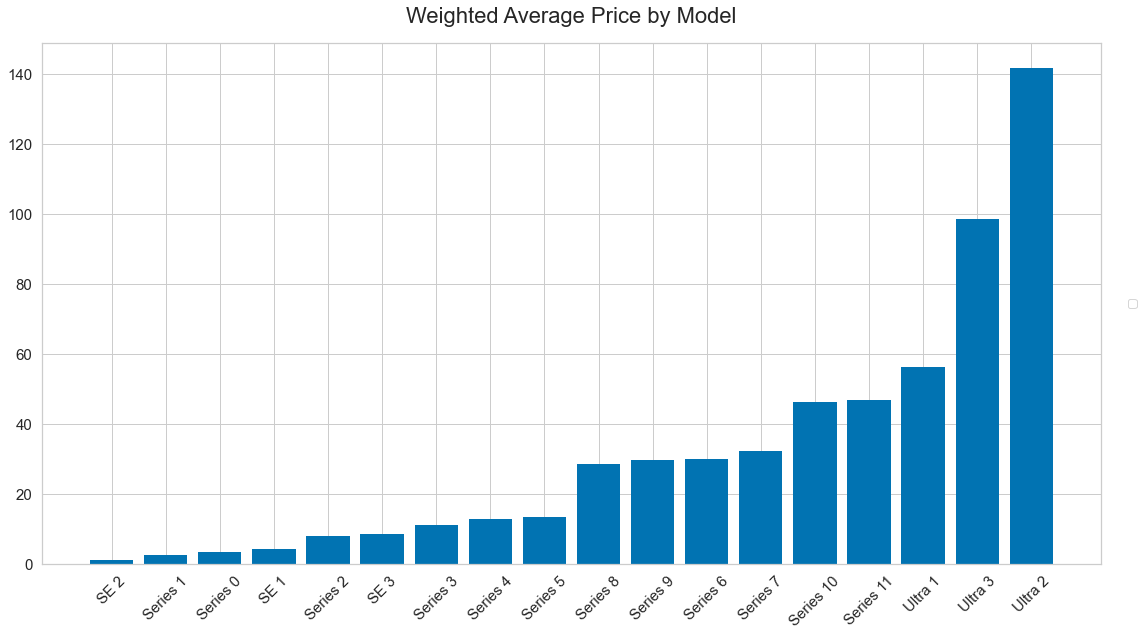

In [19]:
import pandas as pd
model_means = df.groupby('model')['price'].mean()
model_weights = df['model'].value_counts(normalize=True).reindex(model_means.index)

# Create DataFrame with reset_index
weighted_means = pd.DataFrame({
    'model': model_means.index,
    'price': model_means * model_weights
}).reset_index(drop=True)

plot_by(
    weighted_means,
    by='mean',
    title='Weighted Average Price by Model',
    save_path=IMAGES_DIR / 'weighted_means.png'
)

This shows that older Series models, while numerous and priced highly, do not actually contribute much to the overall smartwatch market.

The majority of the market is occupied by the Ultra series and the two most recent Series.

### How do these listing prices compare to original retail price?

In [20]:
from src.graphics import plot_resale_comparison

In [21]:
retail_price_ranges = {
    'Series 0': (349, 399),
    'Series 1': (269, 299),
    'Series 2': (369, 399),
    'Series 3': (329, 1299),   # ceramic edition max
    'Series 4': (399, 1499),   # stainless/edition peak era
    'Series 5': (399, 1399),   # ceramic edition max
    'Series 6': (399, 849),    # titanium/stainless cellular
    'Series 7': (399, 849),
    'Series 8': (399, 849),
    'Series 9': (399, 849),
    'Series 10': (399, 749),
    'Series 11': (399, 749),

    'SE 1': (279, 359),
    'SE 2': (249, 329),
    'SE 3': (249, 329),

    'Ultra 1': (799, 999),
    'Ultra 2': (799, 999),
    'Ultra 3': (799, 999)
}


unique_families = df['family'].dropna().unique()
unique_models = df['model'].dropna().unique()

Ultra_models = sorted([f for f in unique_models if 'Ultra' in f],
                     key=lambda x: int(x.split()[-1]))
Series_models = sorted([f for f in unique_models if 'Series' in f],
                     key=lambda x: int(x.split()[-1]))
SE_models = sorted([f for f in unique_models if 'SE' in f],
                     key=lambda x: int(x.split()[-1]))


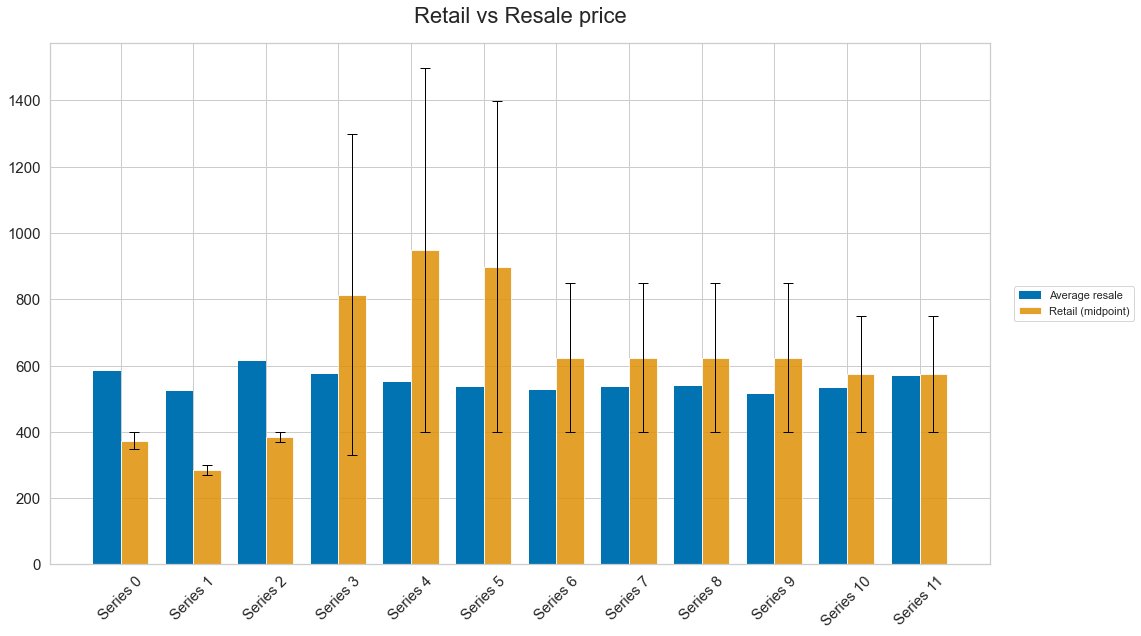

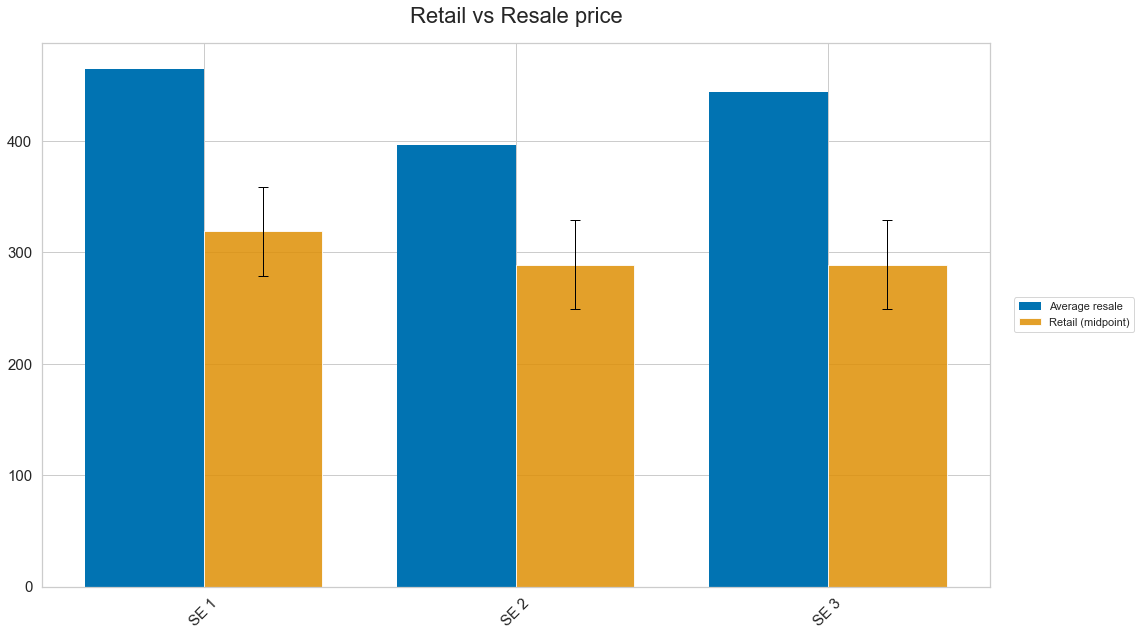

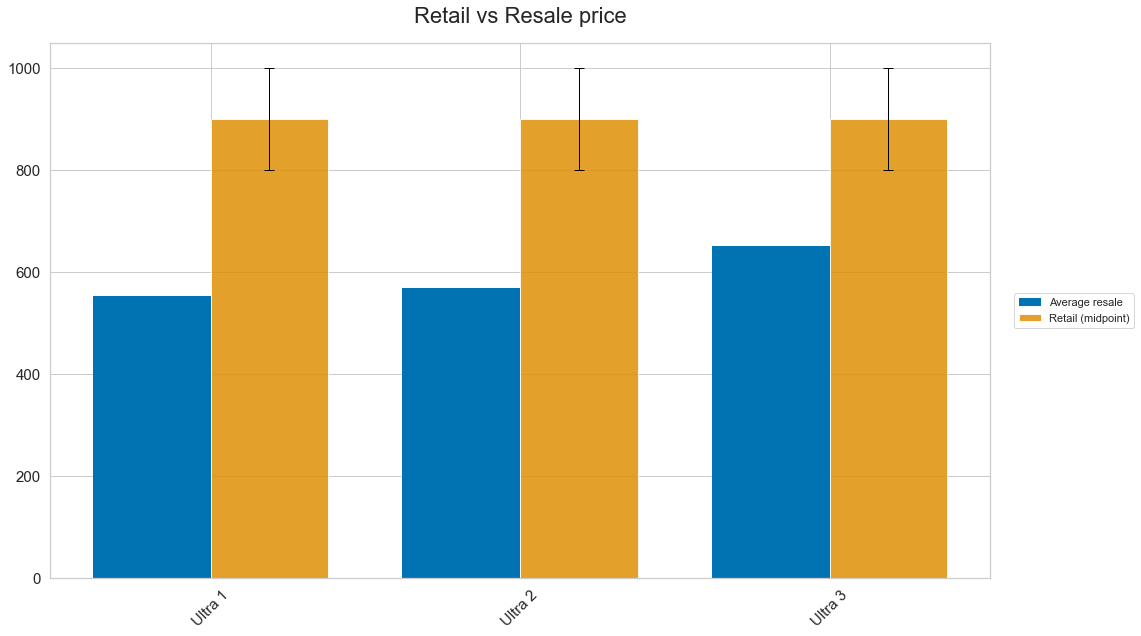

In [22]:
# Series
plot_by(
    retail_models,
    by='mean',
    title='Retail vs Resale price',
    model_list=Series_models,
    retail_prices=retail_price_ranges,
    order= Series_models,
    whiskers=True
)

# SE
plot_by(
    retail_models,
    by='mean',
    title='Retail vs Resale price',
    model_list=SE_models,
    retail_prices=retail_price_ranges,
    order= SE_models,
    whiskers=True
)

# Ultra
plot_by(
    retail_models,
    by='mean',
    title='Retail vs Resale price',
    model_list=Ultra_models,
    retail_prices=retail_price_ranges,
    order= Ultra_models,
    whiskers=True
)

### Key insights:

The oldest Series models (0, 1, and 2) are priced significantly above original retail price. 

SE models are priced significantly above retail.

Ultra models are priced below retail.

Older models are still listed for about the same price as newer ones. Meaning that Apple watches seem to hold value very well.

## Which other factors are driving the list price?

Build linear model and see coefficients

In [23]:
from src.models import build_price_model, _group_rare_categories, _set_reference_level, _add_constant_column,_compute_vif

from src.graphics import display_model_results

In [24]:
# Group seller_id by number of listings
seller_counts = df['seller_id'].value_counts()

# Define seller groups:
# - Individual sellers: 1-2 listings
# - Power sellers: 3+ listings
df['seller_type'] = df['seller_id'].map(
    lambda x: 'Individual (1 listing)' if seller_counts[x] <= 1 
              else 'Power Seller (2+ listings)'
)


In [25]:
seller_counts = df['seller_id'].value_counts()

df['power_seller'] = df['seller_id'].map(seller_counts > 5).astype(int)


In [26]:
results = build_price_model(
    df,
    log_transform=True,
    exclude_features=['title', 'seller_id', 'family', 'country_grouped']
)

C:\Users\13039\git_repos\Apple-smartwatch-analysis\src\models.py:457: UserWarning: Dropped 353 rows containing NaN values.
  warnings.warn(f"Dropped {dropped_na} rows containing NaN values.")


R²:  0.414
MAE: $85.85


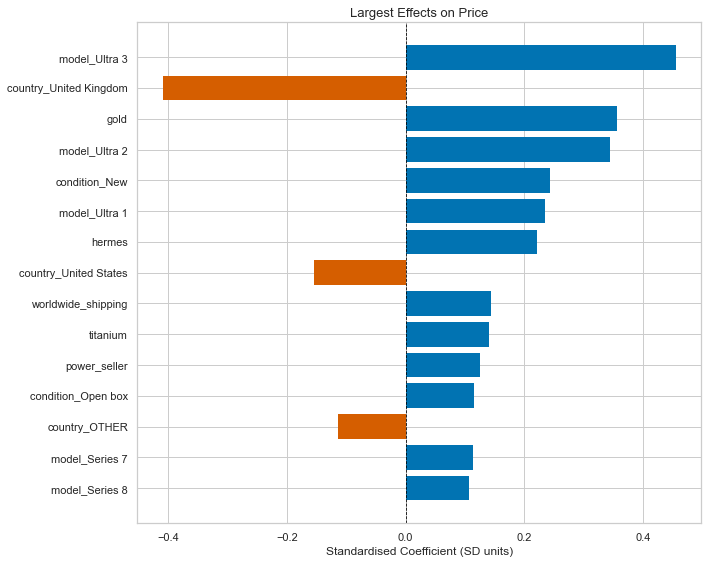

               feature  coefficient percent_effect std_effect
         model_Ultra 3     0.345920         +41.3%      0.455
country_United Kingdom    -0.359719         -30.2%     -0.409
                  gold     0.396299         +48.6%      0.357
         model_Ultra 2     0.209535         +23.3%      0.344
         condition_New     0.135713         +14.5%      0.244
         model_Ultra 1     0.203406         +22.6%      0.235
                hermes     0.314232         +36.9%      0.222
 country_United States    -0.102019          -9.7%     -0.155
    worldwide_shipping     0.102385         +10.8%      0.145
              titanium     0.147301         +15.9%      0.140
          power_seller     0.071454          +7.4%      0.125
    condition_Open box     0.073958          +7.7%      0.115
         country_OTHER    -0.160568         -14.8%     -0.113
        model_Series 7     0.124219         +13.2%      0.113
        model_Series 8     0.124415         +13.2%      0.106


In [27]:
display_model_results(results, top_n=15, save_path = IMAGES_DIR / 'feature_importance.png')

In [28]:
import numpy as np

np.expm1(.4)

0.49182469764127035

## Impact of country on list price or, how normal is the UK?

Put countries with < 30 listings in 'Other' category.

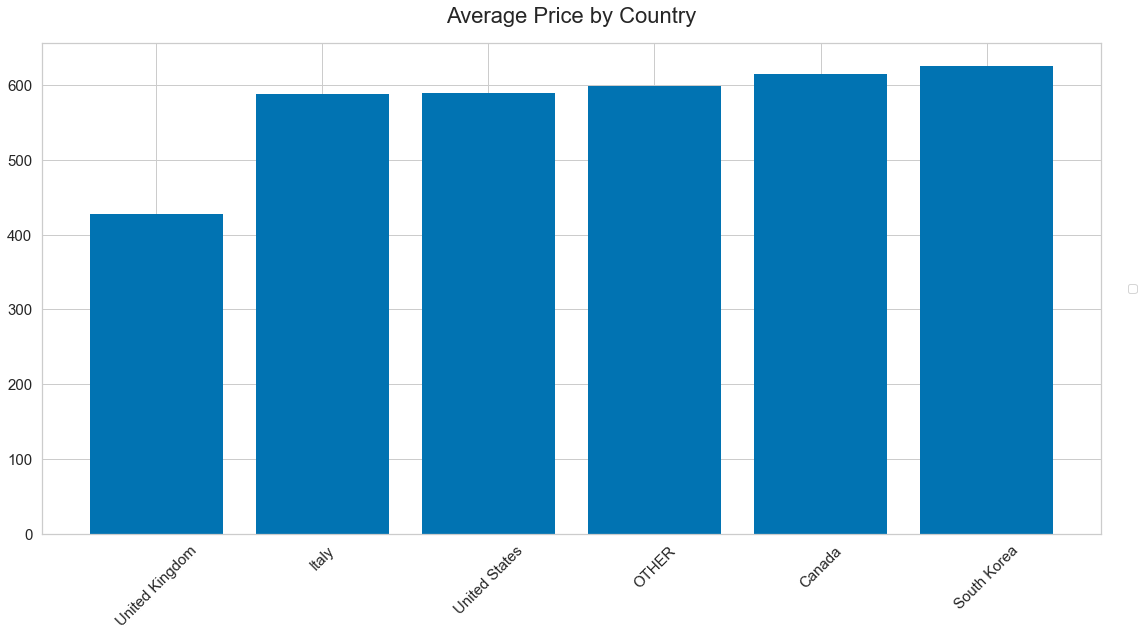

In [29]:
# Create grouped country column
country_counts = df['country'].value_counts()
df['country_grouped'] = df['country'].where(
    df['country'].isin(country_counts[country_counts >= 30].index),
    'OTHER'
)

# Plot
plot_by(
    df,
    by='mean',
    column='country_grouped',
    title='Average Price by Country',
    save_path=IMAGES_DIR / 'price_by_country.png'
)

The UK here certainly does look like an outlier. It's about 150 dollars below average.

### Look at price deviations from the global mean by model by country

Meaning, how does it compare to other countries by model listings? Is it that only cheap, old smartwatches are sold in the UK and that is why it's cheaper there on average?

In [30]:
other_countries = [
    country 
    for country in df['country'].value_counts().index 
    if (df['country'].value_counts().loc[country] < 30)
]

df_copy = df.copy()

df_copy = df_copy.replace({country:'Other' for country in other_countries})

import pandas as pd
df_copy_means = pd.DataFrame(df_copy.groupby(['country', 'model'])['price'].mean().unstack())

df_copy_counts = pd.DataFrame(df_copy.groupby(['country', 'model']).size().unstack(fill_value=0))

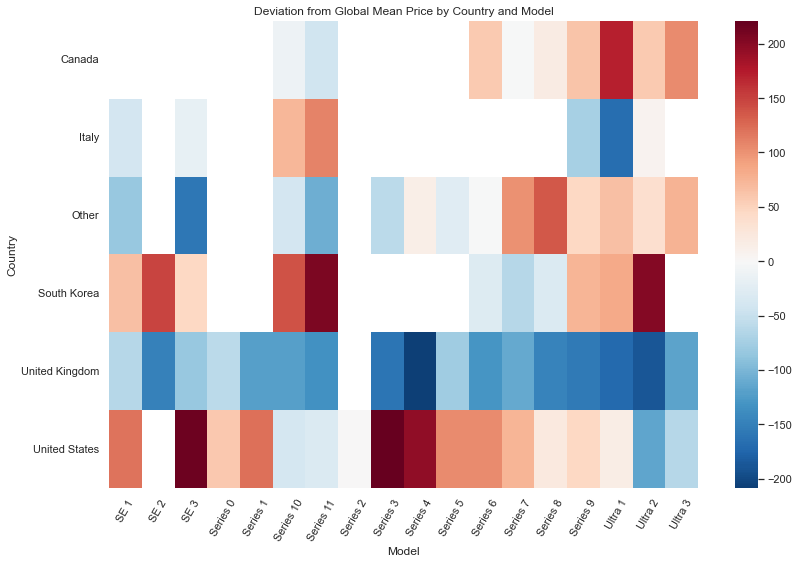

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

deviation_df_mean = df_copy_means.subtract(
    df_copy_means.mean(axis=0),
    axis=1
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    deviation_df_mean,
    cmap='RdBu_r',
    center=0
)

plt.xticks(rotation=60)
plt.yticks(rotation=0)
plt.title('Deviation from Global Mean Price by Country and Model')
plt.xlabel('Model')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

This plot looks at deviation from the global mean by model and country. 

White &rarr; average (or no data)

Blue &rarr; cheaper than average

Red &rarr; more expensive than average

### Key insights:

Prices of models are roughly evenly distributed. Meaning is aren't just one or two great anomalies that make the difference in price.

## ANOVA

In [32]:
import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations

# ── 1. Filter countries with <30 entries into 'Other' ──────────────────────────
country_counts = df['country'].value_counts()
small_countries = country_counts[country_counts < 2].index
df['country_grouped'] = df['country'].where(~df['country'].isin(small_countries), other='Other')

# ── 2. One-way ANOVA across all country groups ─────────────────────────────────
groups = [grp['price'].dropna().values for _, grp in df.groupby('country_grouped')]
group_labels = [name for name, _ in df.groupby('country_grouped')]

f_stat, p_value = stats.f_oneway(*groups)

# Effect size: eta-squared (SS_between / SS_total)
grand_mean = df['price'].dropna().mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total   = sum(((df['price'].dropna() - grand_mean) ** 2))
eta_squared = ss_between / ss_total

print("=" * 55)
print("ONE-WAY ANOVA  —  Price ~ Country")
print("=" * 55)
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_value:.4e}")
print(f"  η²          : {eta_squared:.4f}  ({eta_squared*100:.1f}% of variance explained)")

# ── 3. UK-specific contrast (UK vs. all other groups pooled) ───────────────────
uk_label = 'United Kingdom'

if uk_label in group_labels:
    uk_prices    = df.loc[df['country_grouped'] == uk_label, 'price'].dropna().values
    non_uk_prices = df.loc[df['country_grouped'] != uk_label, 'price'].dropna().values

    # Welch's t-test (does not assume equal variances)
    t_stat, p_uk = stats.ttest_ind(uk_prices, non_uk_prices, equal_var=False)

    # Effect size: Cohen's d
    pooled_std = np.sqrt((uk_prices.std(ddof=1)**2 + non_uk_prices.std(ddof=1)**2) / 2)
    cohens_d   = (uk_prices.mean() - non_uk_prices.mean()) / pooled_std

    # Eta-squared for UK contrast
    all_uk_contrast  = np.concatenate([uk_prices, non_uk_prices])
    grand_mean_uk    = all_uk_contrast.mean()
    ss_between_uk    = (len(uk_prices)    * (uk_prices.mean()    - grand_mean_uk) ** 2 +
                        len(non_uk_prices) * (non_uk_prices.mean() - grand_mean_uk) ** 2)
    ss_total_uk      = np.sum((all_uk_contrast - grand_mean_uk) ** 2)
    eta_sq_uk        = ss_between_uk / ss_total_uk

    print()
    print("=" * 55)
    print("UK CONTRAST  —  United Kingdom vs. Rest")
    print("=" * 55)
    print(f"  UK mean price       : {uk_prices.mean():.2f}  (n={len(uk_prices)})")
    print(f"  Non-UK mean price   : {non_uk_prices.mean():.2f}  (n={len(non_uk_prices)})")
    print(f"  Mean difference     : {uk_prices.mean() - non_uk_prices.mean():+.2f}")
    print(f"  Welch t-statistic   : {t_stat:.4f}")
    print(f"  p-value             : {p_uk:.4e}")
    print(f"  Cohen's d           : {cohens_d:.4f}")
    print(f"  η² (UK contrast)    : {eta_sq_uk:.4f}")
else:
    print(f"\n  ⚠  '{uk_label}' not found after grouping (too few entries — absorbed into Other).")

# ── 4. Post-hoc Tukey HSD (all pairwise comparisons) ──────────────────────────
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df.loc[df['country_grouped'].notna(), 'price'],
    groups=df.loc[df['country_grouped'].notna(), 'country_grouped'],
    alpha=0.05
)

print()
print("=" * 55)
print("POST-HOC TUKEY HSD  —  Pairwise comparisons")
print("=" * 55)
print(tukey.summary())

ONE-WAY ANOVA  —  Price ~ Country
  F-statistic : 22.1224
  p-value     : 7.3001e-54
  η²          : 0.1181  (11.8% of variance explained)

UK CONTRAST  —  United Kingdom vs. Rest
  UK mean price       : 427.61  (n=212)
  Non-UK mean price   : 592.51  (n=2116)
  Mean difference     : -164.91
  Welch t-statistic   : -19.0205
  p-value             : 1.7502e-52
  Cohen's d           : -1.2386
  η² (UK contrast)    : 0.0970

POST-HOC TUKEY HSD  —  Pairwise comparisons
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
    group1         group2      meandiff p-adj    lower     upper   reject
-------------------------------------------------------------------------
     Australia         Canada -179.7367 0.0022 -323.9007  -35.5727   True
     Australia         France -332.7179 0.0009 -586.5447   -78.891   True
     Australia        Germany -236.5214 0.0013 -420.6668  -52.3761   True
     Australia         Greece  -74.7179    1.0 -443.0086  293.5729  False
     Australi

In [33]:
from scipy import stats
import pandas as pd
import numpy as np

# Columns to test (excluding 'price' which is the target variable)
columns_to_test = ['condition', 'case_size', 'worldwide_shipping',
                    'country', 'model', 'family', 'hermes', 'cellular', 
                   'titanium', 'gold', 'premium_band', 'ceramic']

print("=" * 90)
print("ONE-WAY ANOVA TESTS: Price by Each Categorical Variable")
print("=" * 90)
print(f"{'Column':<20} {'F-statistic':>15} {'P-value':>20} {'η² (Effect Size)':>18}")
print("-" * 90)

results = []

for col in columns_to_test:
    if col not in df.columns:
        continue
    
    # Skip binary columns (only 2 groups) - use t-test instead
    n_groups = df[col].nunique()
    
    if n_groups < 2:
        continue
    
    # For seller_id and title (too many unique values), skip or sample
    if col in ['seller_id', 'title'] and n_groups > 100:
        # Skip variables with too many groups
        f_stat, p_value, eta_sq = np.nan, np.nan, np.nan
        results.append({
            'column': col,
            'f_statistic': f_stat,
            'p_value': p_value,
            'eta_squared': eta_sq,
            'n_groups': n_groups,
            'note': 'Too many groups (>100)'
        })
        print(f"{col:<20} {'N/A':>15} {'N/A':>20} {'N/A':>18} (too many groups)")
        continue
    
    try:
        # One-Way ANOVA
        f_stat, p_value = stats.f_oneway(*[group['price'].values 
                                           for name, group in df.groupby(col)])
        
        # Effect size: Eta-squared (η²) = SS_between / SS_total
        grand_mean = df['price'].mean()
        ss_between = sum(len(group) * (group.mean() - grand_mean)**2 
                        for name, group in df.groupby(col)['price'])
        ss_total = sum((price - grand_mean)**2 for price in df['price'])
        eta_sq = float(ss_between / ss_total)
        
        results.append({
            'column': col,
            'f_statistic': f_stat,
            'p_value': p_value,
            'eta_squared': eta_sq,
            'n_groups': n_groups
        })
        
        # Format p-value
        if p_value < 1e-10:
            p_str = f"{p_value:.2e}"
        else:
            p_str = f"{p_value:.4f}"
        
        print(f"{col:<20} {f_stat:>15.4f} {p_str:>20} {eta_sq:>17.4f}")
        
    except Exception as e:
        results.append({
            'column': col,
            'f_statistic': np.nan,
            'p_value': np.nan,
            'eta_squared': np.nan,
            'n_groups': n_groups,
            'note': str(e)
        })
        print(f"{col:<20} {'Error':>15} {'Error':>20} {'Error':>18}")

print("=" * 90)

# Summary table
results_df = pd.DataFrame(results)
significant = results_df[results_df['p_value'] < 0.05].sort_values('eta_squared', ascending=False)

print("\n" + "=" * 90)
print("SIGNIFICANT PREDICTORS (p < 0.05), sorted by effect size")
print("=" * 90)
print(f"{'Column':<20} {'F-statistic':>15} {'P-value':>20} {'η²':>10}")
print("-" * 90)

for _, row in significant.iterrows():
    p_str = f"{row['p_value']:.2e}" if row['p_value'] < 1e-10 else f"{row['p_value']:.4f}"
    print(f"{row['column']:<20} {row['f_statistic']:>15.4f} {p_str:>20} {row['eta_squared']:>10.4f}")

ONE-WAY ANOVA TESTS: Price by Each Categorical Variable
Column                   F-statistic              P-value   η² (Effect Size)
------------------------------------------------------------------------------------------
condition                    19.6276             7.05e-29            0.0634
case_size                     6.4770               0.0000            0.0222
worldwide_shipping          198.7365             2.28e-43            0.0787
country                      16.6704             5.42e-52            0.1207
model                        16.0575             3.96e-45            0.1053
family                       33.0553             7.09e-15            0.0276
hermes                       37.8777               0.0000            0.0160
cellular                      0.1257               0.7229            0.0001
titanium                      1.3264               0.2496            0.0006
gold                        350.4441             5.97e-73            0.1309
premium_band    

In [34]:
significant['percent_of_price'] = significant['eta_squared'].mul(100)

<BarContainer object of 9 artists>

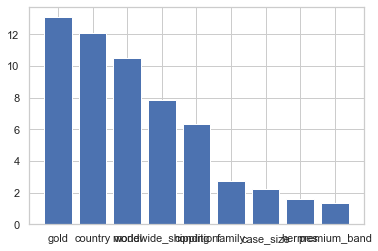

In [35]:
plt.bar(significant['column'],
       significant['percent_of_price'])


In [36]:
from scipy import stats
import pandas as pd
import numpy as np

# Group seller_id by number of listings
seller_counts = df['seller_id'].value_counts()

# Define seller groups:
# - Individual sellers: 1-2 listings
# - Power sellers: 3+ listings
df['seller_type'] = df['seller_id'].map(
    lambda x: 'Individual (1-2 listings)' if seller_counts[x] <= 2 
              else 'Power Seller (3+ listings)'
)

# Run One-Way ANOVA
groups = [group['price'].values for name, group in df.groupby('seller_type')]
f_stat, p_value = stats.f_oneway(*groups)

# Calculate Eta-squared (η²)
grand_mean = df['price'].mean()
ss_between = sum(len(group) * (group.mean() - grand_mean)**2 
                for name, group in df.groupby('seller_type')['price'])
ss_total = sum((price - grand_mean)**2 for price in df['price'])
eta_squared = float(ss_between / ss_total)

print("=" * 80)
print("ONE-WAY ANOVA: Price by Seller Type (Power Sellers vs Individuals)")
print("=" * 80)
print()
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.6e}")
print(f"η² (effect): {eta_squared:.4f}")
print()
print(f"Significant at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")
print()
print("=" * 80)
print("EFFECT SIZE INTERPRETATION")
print("=" * 80)
print(f"η² = {eta_squared:.4f} = {eta_squared*100:.2f}% of price variance explained by seller type")
print()
if eta_squared < 0.01:
    interpretation = "Very small/negligible effect"
elif eta_squared < 0.06:
    interpretation = "Small effect"
elif eta_squared < 0.14:
    interpretation = "Medium effect"
else:
    interpretation = "Large effect"
print(f"Interpretation: {interpretation}")
print()
print("=" * 80)
print("GROUP STATISTICS")
print("=" * 80)
seller_stats = df.groupby('seller_type')['price'].agg([
    ('mean_price', 'mean'),
    ('std_price', 'std'),
    ('n_samples', 'count'),
    ('min_price', 'min'),
    ('max_price', 'max')
]).round(2)

print(seller_stats.to_string())
print()
print("=" * 80)
print("SELLER DISTRIBUTION")
print("=" * 80)
print(f"Total unique sellers: {df['seller_id'].nunique()}")
print(f"Individual sellers (1-2 listings): {(df['seller_type'] == 'Individual (1-2 listings)').sum()} listings")
print(f"Power sellers (3+ listings): {(df['seller_type'] == 'Power Seller (3+ listings)').sum()} listings")

ONE-WAY ANOVA: Price by Seller Type (Power Sellers vs Individuals)

F-statistic: 43.2651
P-value:     5.884641e-11
η² (effect): 0.0183

Significant at α=0.05: Yes

EFFECT SIZE INTERPRETATION
η² = 0.0183 = 1.83% of price variance explained by seller type

Interpretation: Small effect

GROUP STATISTICS
                            mean_price  std_price  n_samples  min_price  max_price
seller_type                                                                       
Individual (1-2 listings)       561.46     139.02       1449     120.00     1199.0
Power Seller (3+ listings)      603.92     168.88        879     249.99      999.0

SELLER DISTRIBUTION
Total unique sellers: 1430
Individual sellers (1-2 listings): 1449 listings
Power sellers (3+ listings): 879 listings


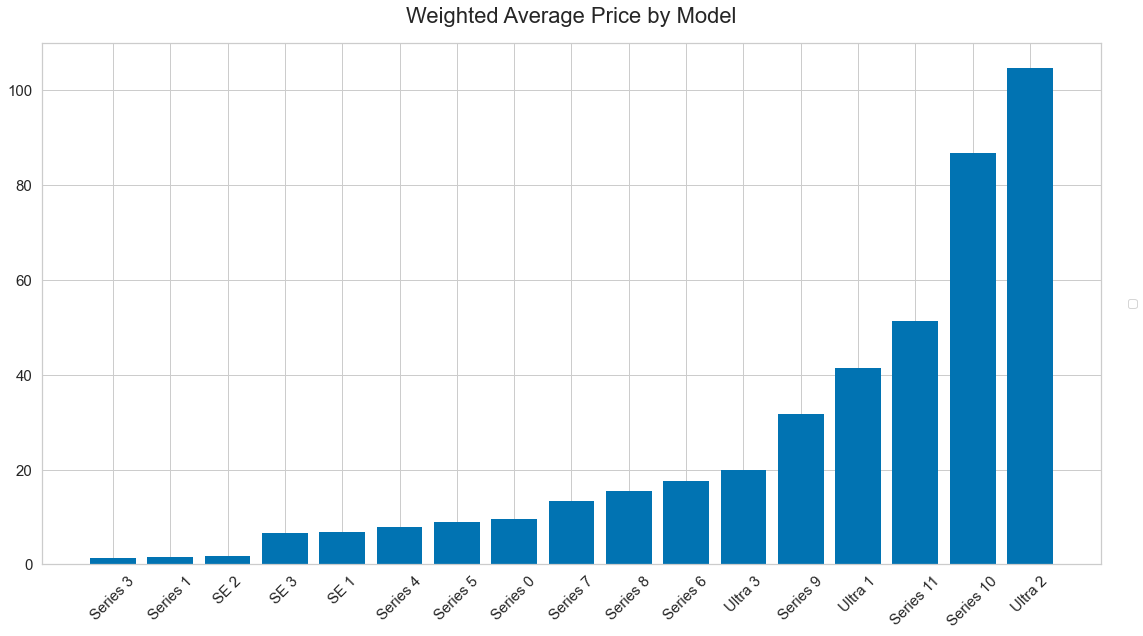

In [37]:
uk = df[df['country'] == 'United Kingdom']

uk_model_means = uk.groupby('model')['price'].mean()
uk_model_weights = uk['model'].value_counts(normalize=True).reindex(uk_model_means.index)

# Create DataFrame with reset_index
uk_weighted_means = pd.DataFrame({
    'model': uk_model_means.index,
    'price': uk_model_means * uk_model_weights
}).reset_index(drop=True)

plot_by(
    uk_weighted_means,
    by='mean',
    title='Weighted Average Price by Model',
    save_path=IMAGES_DIR / 'weighted_means.png'
)

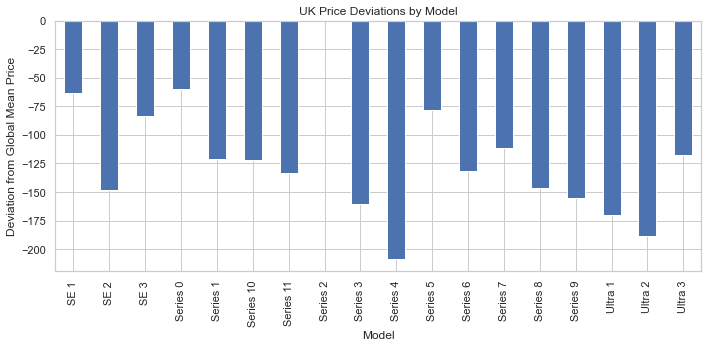

In [38]:
uk_deviation = deviation_df_mean.loc['United Kingdom']

uk_deviation.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.axhline(0, color='black', linewidth=1)

plt.title('UK Price Deviations by Model')
plt.ylabel('Deviation from Global Mean Price')
plt.xlabel('Model')

plt.tight_layout()
plt.show()

Same chart but now each price is multiplied by count.

This will tell us not which models are most underpriced, but rather which models contribute to lower pricing across the country.

The idea is that, series 4 models, say, are about $200 below average. But there if there are only 3 listings, that price difference won't contribute much to the average price from the UK. However, more expensive models, like the ultra series, if there are a lot of them then even though they are priced slightly higher, they can have a greater cumulative effect.

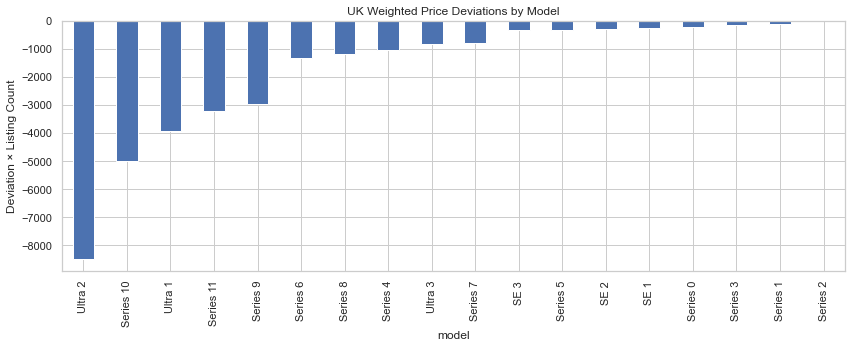

In [39]:
weighted_deviation = (
    deviation_df_mean.loc['United Kingdom']
    * df_copy_counts.loc['United Kingdom']
)

weighted_deviation.sort_values().plot(
    kind='bar',
    figsize=(12, 5)
)

plt.axhline(0, color='black')

plt.title('UK Weighted Price Deviations by Model')
plt.ylabel('Deviation × Listing Count')

plt.tight_layout()
plt.show()

This tells us that cheap Ultra 2s contribute a lot. 

Let's convert that to a percent and plot.

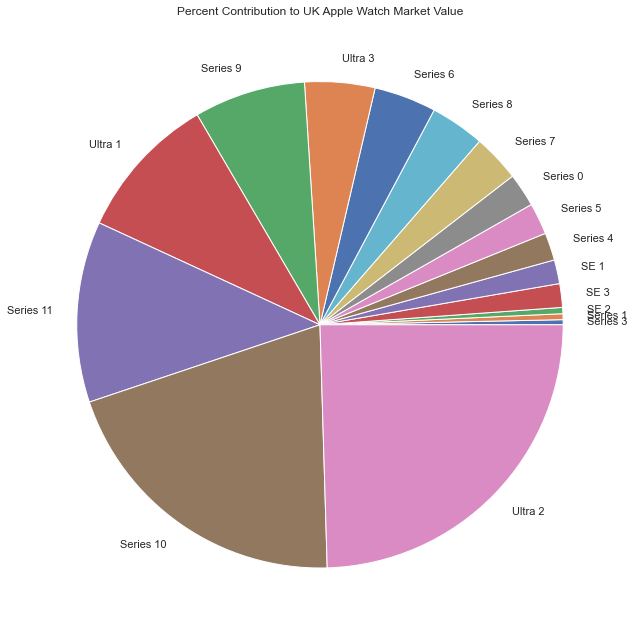

In [40]:
uk_total_value = (df[df['country'] == 'United Kingdom']
                  .groupby('model')['price']
                  .sum()
)


uk_pct_contribution = (
    uk_total_value
    / uk_total_value.sum()
    * 100
)

uk_pct_contribution.sort_values().plot(
    kind='pie',
    figsize=(12,9)
)

plt.xlabel('')
plt.ylabel('')

plt.title('Percent Contribution to UK Apple Watch Market Value')

plt.tight_layout()
plt.show()

This plot means that most listings in the UK are globally popular smartwatches, and they are just listed on average lower than in other countries.

# Heres some code that will compute statistics designed to determine how different the UK is

In [41]:
config_cols = [
    'model',
    'case_size',
    'cellular',
    'titanium',
    'hermes',
    'premium_band'
]

In [42]:
import pandas as pd

config_cols = [
    'model'
]

# Global medians
global_median = (
    df.groupby(config_cols)['price']
    .median()
    .rename('global_median')
)

# UK medians
uk_median = (
    df[df['country'] == 'United Kingdom']
    .groupby(config_cols)['price']
    .median()
    .rename('uk_median')
)

# Combine
price_compare = pd.concat(
    [global_median, uk_median],
    axis=1
).dropna()

# Relative deviation
price_compare['pct_diff'] = (
    (price_compare['uk_median']
     - price_compare['global_median'])
    / price_compare['global_median']
    * 100
)

# Biggest anomalies
price_compare.sort_values(
    'pct_diff',
    ascending=False
).head(20)

,global_median,uk_median,pct_diff
model,,,
Ultra 2,530.000,490.000,-7.547170
Ultra 3,649.000,599.000,-7.704160
Series 5,550.000,462.945,-15.828182
Series 8,500.000,420.000,-16.000000
Series 0,574.990,462.495,-19.564688
Series 10,499.995,399.000,-20.199202
Series 7,500.000,399.000,-20.200000
Series 11,550.000,434.495,-21.000909
SE 3,449.615,354.750,-21.099163


Z-score

In [43]:
# Global stats
global_stats = (
    df.groupby(config_cols)['price']
    .agg(['mean', 'std'])
    .rename(columns={
        'mean': 'global_mean',
        'std': 'global_std'
    })
)

# UK means
uk_mean = (
    df[df['country'] == 'United Kingdom']
    .groupby(config_cols)['price']
    .mean()
    .rename('uk_mean')
)

# Combine
zscore_df = pd.concat(
    [global_stats, uk_mean],
    axis=1
).dropna()

# Z-score
zscore_df['z_score'] = (
    (zscore_df['uk_mean']
     - zscore_df['global_mean'])
    / zscore_df['global_std']
)

# Largest positive UK anomalies
zscore_df.sort_values(
    'z_score',
    ascending=False
).head(20)

,global_mean,global_std,uk_mean,z_score
model,,,,
Series 0,583.595714,164.858631,498.495000,-0.516204
Ultra 2,569.001032,138.465851,486.793778,-0.593701
Series 10,533.149847,144.598195,442.842683,-0.624539
Ultra 3,651.422258,90.578164,594.712857,-0.626082
SE 1,464.930476,149.454077,353.750000,-0.743911
Series 5,623.620204,196.766172,468.972500,-0.785947
Series 11,569.337151,137.422247,447.698333,-0.885146
Series 8,557.967155,164.454905,403.367500,-0.940073
Series 7,573.325984,174.525381,401.135714,-0.986620


UK share vs expected share

In [44]:
# Global counts
global_counts = (
    df.groupby(config_cols)
    .size()
    .rename('global_count')
)

# UK counts
uk_counts = (
    df[df['country'] == 'United Kingdom']
    .groupby(config_cols)
    .size()
    .rename('uk_count')
)

# Combine
share_df = pd.concat(
    [global_counts, uk_counts],
    axis=1
).fillna(0)

# Remove small samples
MIN_COUNT = 10

share_df = share_df[
    (share_df['global_count'] >= MIN_COUNT)
    &(share_df['uk_count'] >= MIN_COUNT/2)
]

# Percentages
share_df['global_pct'] = (
    share_df['global_count']
    / share_df['global_count'].sum()
)

share_df['uk_pct'] = (
    share_df['uk_count']
    / share_df['uk_count'].sum()
)

# Representation index
share_df['representation_index'] = (
    share_df['uk_pct']
    / share_df['global_pct']
)

# Most overrepresented in UK
share_df.sort_values(
    'representation_index',
    ascending=False
).head(20)


,global_count,uk_count,global_pct,uk_pct,representation_index
model,,,,,
Series 10,196,41.0,0.095750,0.216931,2.265603
Series 9,129,19.0,0.063019,0.100529,1.595218
Series 11,186,24.0,0.090865,0.126984,1.397508
Series 4,43,5.0,0.021006,0.026455,1.259382
Ultra 1,229,23.0,0.111871,0.121693,1.087798
Series 6,118,10.0,0.057645,0.052910,0.917855
Ultra 2,562,45.0,0.274548,0.238095,0.867226
Series 8,116,8.0,0.056668,0.042328,0.746944
Series 7,127,7.0,0.062042,0.037037,0.596967


In [45]:
# COMBINED


combined = (
    price_compare[['pct_diff']]
    .join(zscore_df[['z_score']])
    .join(share_df[['representation_index',
                    'global_count',
                    'uk_count']])
)

combined.sort_values(
    ['z_score', 'representation_index'],
    ascending=False
).head(30)

,pct_diff,z_score,representation_index,global_count,uk_count
model,,,,,
Series 0,-19.564688,-0.516204,NaN,NaN,NaN
Ultra 2,-7.547170,-0.593701,0.867226,562.0,45.0
Series 10,-20.199202,-0.624539,2.265603,196.0,41.0
Ultra 3,-7.704160,-0.626082,0.222331,341.0,7.0
SE 1,-29.444444,-0.743911,NaN,NaN,NaN
Series 5,-15.828182,-0.785947,NaN,NaN,NaN
Series 11,-21.000909,-0.885146,1.397508,186.0,24.0
Series 8,-16.000000,-0.940073,0.746944,116.0,8.0
Series 7,-20.200000,-0.986620,0.596967,127.0,7.0


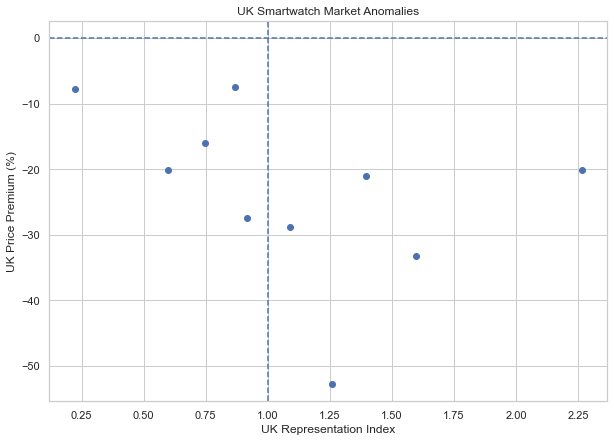

In [46]:
import matplotlib.pyplot as plt

plot_df = combined.dropna()

plt.figure(figsize=(10,7))

plt.scatter(
    plot_df['representation_index'],
    plot_df['pct_diff']
)

plt.axhline(0, linestyle='--')
plt.axvline(1, linestyle='--')

plt.xlabel('UK Representation Index')
plt.ylabel('UK Price Premium (%)')
plt.title('UK Smartwatch Market Anomalies')

plt.show()

# Possible Explanations

In [47]:
# Sure, you could ask for that much







# THIS is a better example
#638 	New 	38.0 	469.98 	Seller_0614 	0 	apple watch series 3 silver aluminium case, fog sport band (gps) mqku2ll/a 	United States 	series 3 	0 	0 	0 	0
# US based company, apple watch series 3 for $469.98 + economy shipping within the us for $24.98.
# This seller also sells a bunch of other stuff, mostly other apple electronics.
# But perhaps it's just a 'vintage' item...






# Let's look at the current gen SE 3 as an example to make this point.
# It retails in the US for like $250 (check this). But the average resale value in this data is ___
# In fact, several online stores (multiple listings from the same seller_id) have it priced at $450 (check)
# I was able to find some of these listings and they come from US based ebay stores. Why would they price s current gen
# watch at such an exhorbitant level? I don't know.

# Perhaps these sellers have leftover stock of these old models and just set the price at an 'optimistic value'
# In the hopes that maybe someday, someone will buy it.



In [48]:
# Take this for example
# New 	NaN 	431.99 	Seller_0029 	0 	apple watch se 3 gps+ cellular midnight aluminum c smart watch mepc4zr/a- 	Italy 	se 3 	0 	1 	0 	0
# Its a 40mm case size, cellular, rubber strap, black apple watch from a big online store
# It's listed for 411 euros, free shipping, from italy. However, on apple/Italy site, the same watch is available for
# 329 euros, free shipping.

# It would be extremely helpful to compare these listing prices with actual sales prices to see if there's a difference.

In [49]:
# FOR THE LIMITATIONS SECTION
# If I go on amazon right now in May of 2026 and search for apple watch se 3, I see many listings for new options around 
# the $200 price point, shipping free. On ebay.com with buyitnow filter
# It's a bit more expensive, around $260.

# If I search for an older model, say series 10 I see on amazon for $250-$300, free shipping. However, in this data
# The majority are listed for between 450-500, and there are zero listings under 300. Where are these entries?


In [50]:
len(df)

2328

In [51]:
len(df['country'].unique())

20

In [52]:
len(df['seller_id'].unique())

1430